## 1- Data Explore


In [1]:
import pandas as pd

In [2]:
#loading train dataset
data = pd.read_csv('ds/fraudTrain.csv')

In [7]:
data.head(1)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  str    
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  str    
 4   category               1296675 non-null  str    
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  str    
 7   last                   1296675 non-null  str    
 8   gender                 1296675 non-null  str    
 9   street                 1296675 non-null  str    
 10  city                   1296675 non-null  str    
 11  state                  1296675 non-null  str    
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long                   129667

In [ ]:
print("data shape" ,data.shape)
#1296675 lines * 23 column

data shape (1296675, 23)


In [8]:
data.describe().apply(lambda s: s.apply('{:,.2f}'.format))

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,"1,296,675.00","1,296,675.00","1,296,675.00","1,296,675.00","1,296,675.00","1,296,675.00","1,296,675.00","1,296,675.00","1,296,675.00","1,296,675.00","1,296,675.00"
mean,"648,337.00","417,192,042,079,726,656.00",70.35,"48,800.67",38.54,-90.23,"88,824.44","1,349,243,636.73",38.54,-90.23,0.01
std,"374,317.97","1,308,806,447,000,240,384.00",160.32,"26,893.22",5.08,13.76,"301,956.36","12,841,278.42",5.11,13.77,0.08
min,0.00,"60,416,207,185.00",1.00,"1,257.00",20.03,-165.67,23.00,"1,325,376,018.00",19.03,-166.67,0.00
25%,"324,168.50","180,042,946,491,150.00",9.65,"26,237.00",34.62,-96.80,743.00,"1,338,750,742.50",34.73,-96.90,0.00
50%,"648,337.00","3,521,417,320,836,166.00",47.52,"48,174.00",39.35,-87.48,"2,456.00","1,349,249,747.00",39.37,-87.44,0.00
75%,"972,505.50","4,642,255,475,285,942.00",83.14,"72,042.00",41.94,-80.16,"20,328.00","1,359,385,375.50",41.96,-80.24,0.00
max,"1,296,674.00","4,992,346,398,065,154,048.00","28,948.90","99,783.00",66.69,-67.95,"2,906,700.00","1,371,816,817.00",67.51,-66.95,1.00


In [9]:
data.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='str')

In [ ]:
#our target is "is_fraud"
print(data["is_fraud"].value_counts())
#0 => 99010 , 1 => 990 impalance

is_fraud
0    99010
1      990
Name: count, dtype: int64


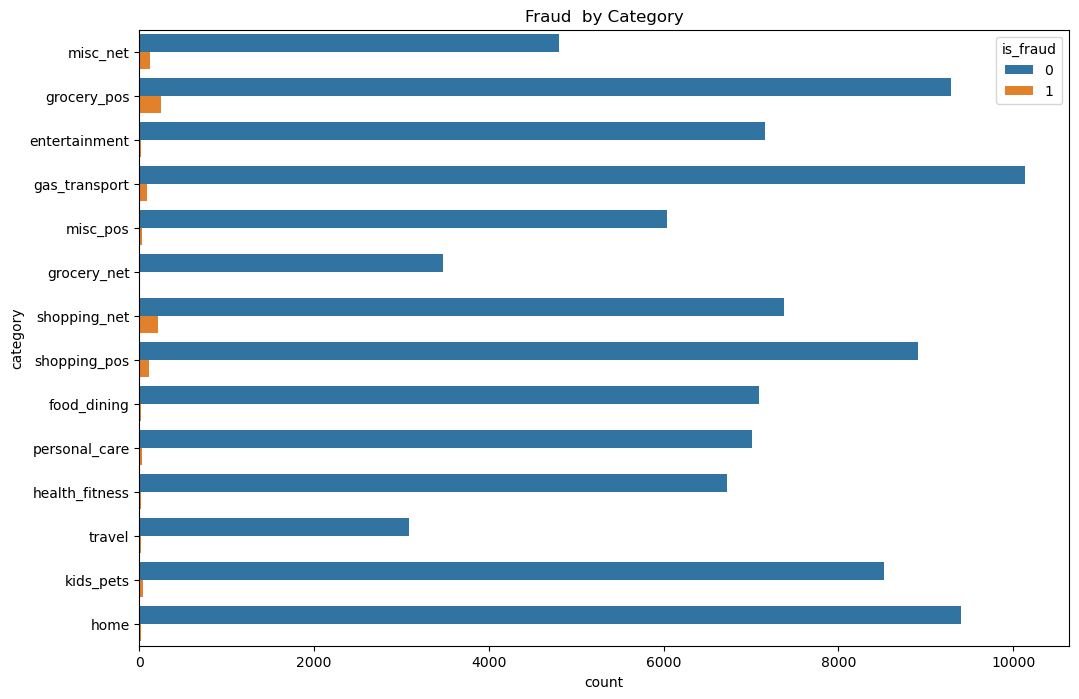

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

#reduce data size so we can represent
data = data.head(550550)

#fraus by category of merchant
plt.figure(figsize=(12,8))
sns.countplot(y='category', hue='is_fraud', data=data)
plt.title('Fraud  by Category')
plt.show()

In [11]:
data["state"].value_counts()

state
TX    7345
NY    6516
PA    6163
CA    4179
MI    3626
OH    3497
IL    3481
FL    3327
AL    3198
MO    3051
MN    2433
AR    2392
NC    2368
VA    2312
WI    2233
SC    2187
KY    2146
IN    2078
IA    2039
WV    2033
MD    2001
GA    1998
OK    1980
NJ    1949
NE    1861
KS    1796
MS    1598
LA    1568
OR    1468
WA    1456
WY    1417
NM    1343
TN    1341
ME    1277
ND    1100
CO    1039
MT     967
MA     937
AZ     898
SD     883
VT     866
UT     815
CT     614
NH     612
ID     452
NV     416
DC     320
HI     196
AK     177
RI      51
Name: count, dtype: int64

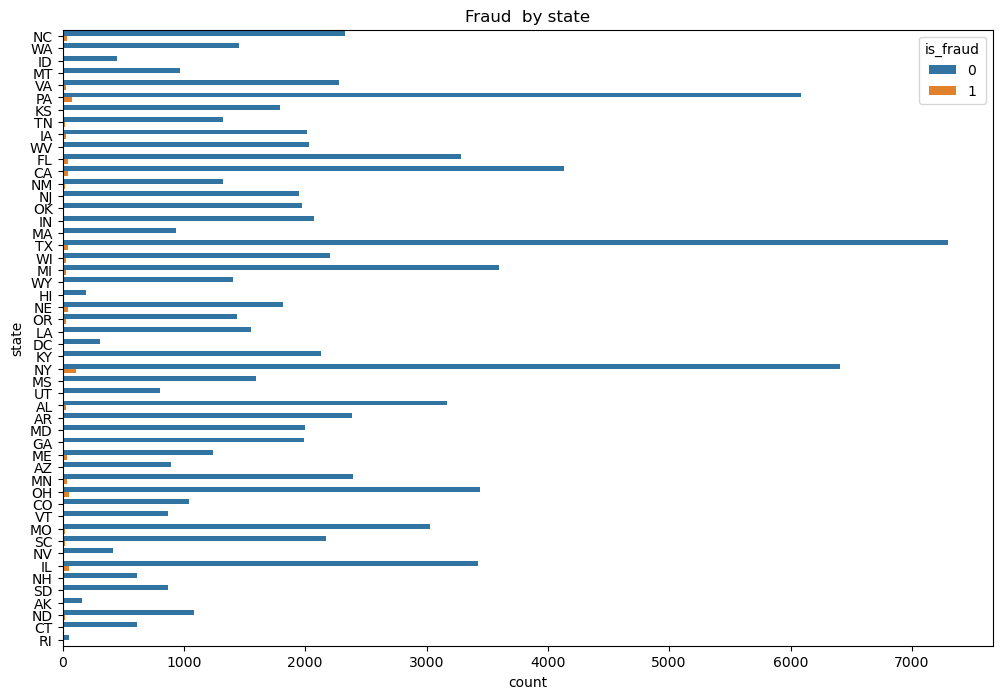

In [13]:
plt.figure(figsize=(12,8))
sns.countplot(y='state', hue='is_fraud', data=data)
plt.title('Fraud  by state')
plt.show()

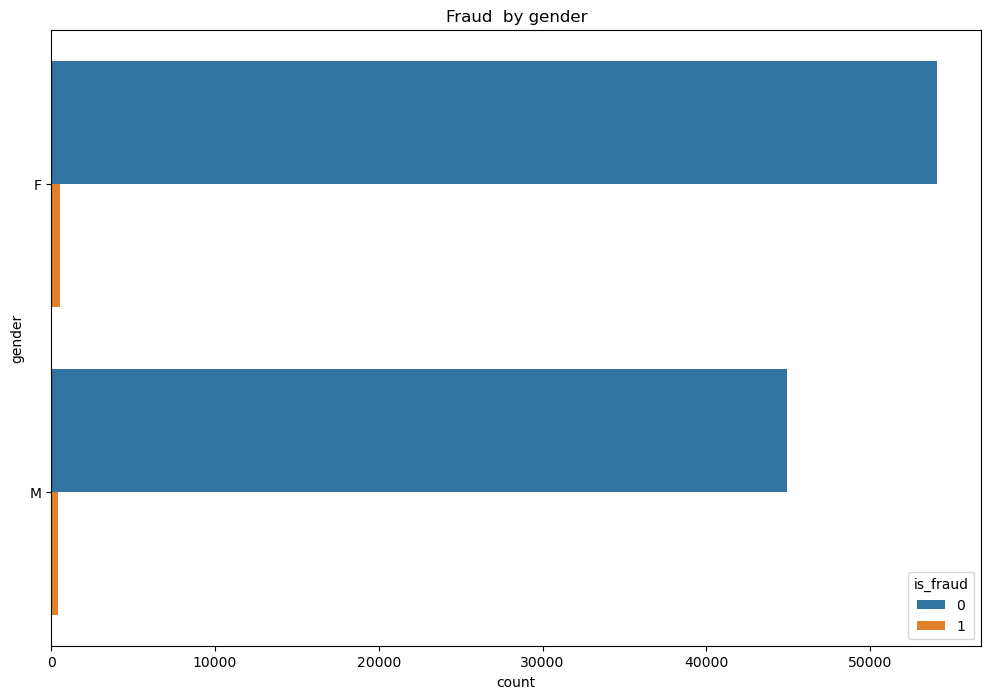

In [15]:
plt.figure(figsize=(12,8))
sns.countplot(y='gender', hue='is_fraud', data=data)
plt.title('Fraud  by gender')
plt.show()

In [6]:
#dath of birth
data['dob'].value_counts()

dob
1977-03-23    426
1988-09-15    364
1981-08-29    355
1989-04-08    277
1972-05-04    276
             ... 
1966-08-03      8
1960-10-28      7
1962-03-14      7
1970-06-25      7
1944-06-17      7
Name: count, Length: 908, dtype: int64

C:\Users\Original Computer\AppData\Local\Temp\ipykernel_11812\431921267.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='age_segment', data=fraud_by_age, palette='magma')


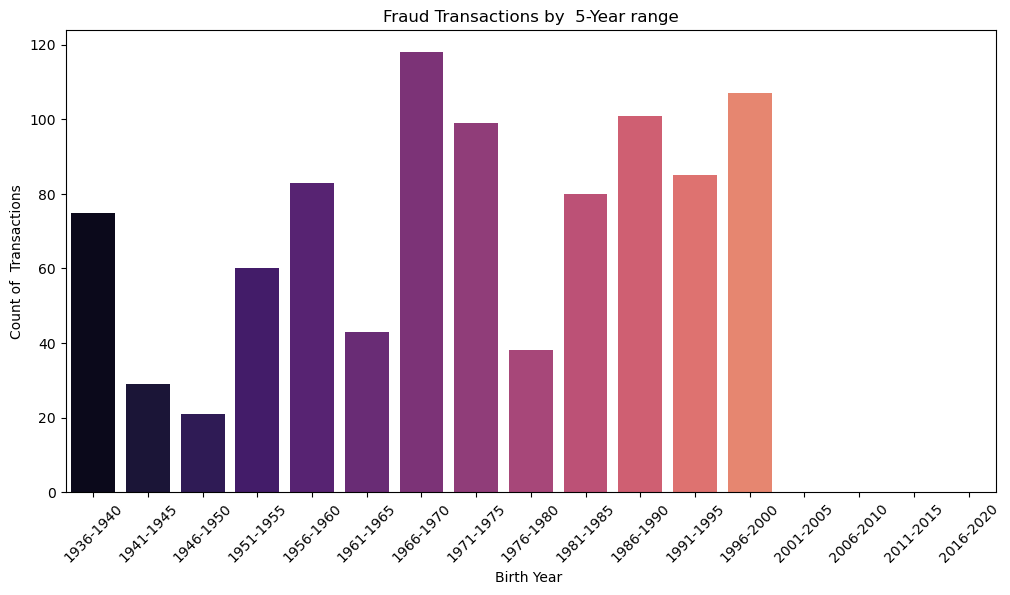

In [ ]:
#date of birth or age could affect fraud transaction

data['dob'] = pd.to_datetime(data['dob'])
data['birth_year'] = data['dob'].dt.year

#segment every 15 years to minimise grapgh size
bins = list(range(1936, 2026, 5)) 
labels = [f"{i}-{i+4}" for i in bins[:-1]]


data['age_segment'] = pd.cut(data['birth_year'], bins=bins, labels=labels, include_lowest=True)


fraud_by_age = data[data['is_fraud'] == 1]


plt.figure(figsize=(12, 6))
sns.countplot(x='age_segment', data=fraud_by_age, palette='magma')
plt.title('Fraud Transactions by  5-Year range')
plt.xlabel('Birth Year ')
plt.ylabel('Count of  Transactions')
plt.xticks(rotation=45)
plt.show()

C:\Users\Original Computer\AppData\Local\Temp\ipykernel_18548\1951759041.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hour_bin', data=fraud_only, palette='viridis', order=labels)


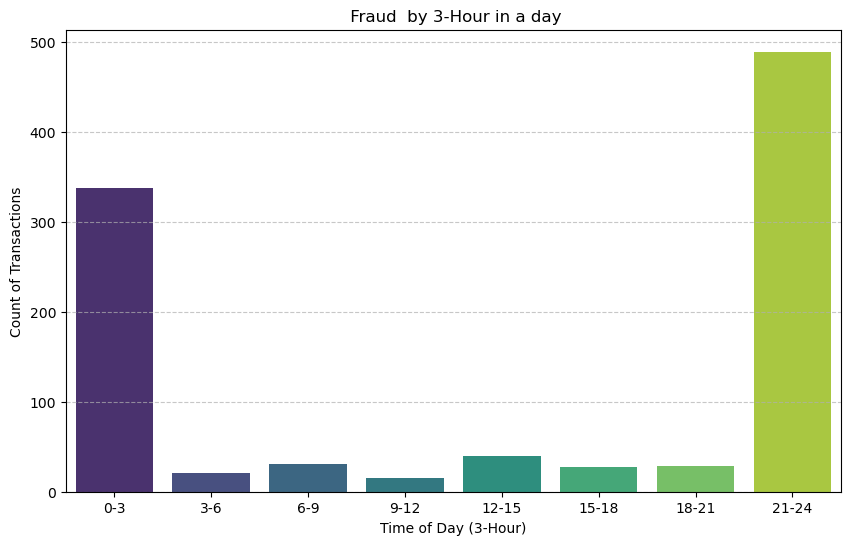

In [15]:

#fraud by hour 
data['trans_date_trans_time'] = pd.to_datetime(data['trans_date_trans_time'])
data['hour'] = data['trans_date_trans_time'].dt.hour

# each 3 hours
bins = [0, 3, 6, 9, 12, 15, 18, 21, 24]
labels = ['0-3', '3-6', '6-9', '9-12', '12-15', '15-18', '18-21', '21-24']
data['hour_bin'] = pd.cut(data['hour'], bins=bins, labels=labels, include_lowest=True)

fraud_only = data[data['is_fraud'] == 1]


plt.figure(figsize=(10, 6))
sns.countplot(x='hour_bin', data=fraud_only, palette='viridis', order=labels)

plt.title(' Fraud  by 3-Hour in a day')
plt.xlabel('Time of Day (3-Hour)')
plt.ylabel('Count of Transactions')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


#most fraud transactions are from 21:00 to 3:00

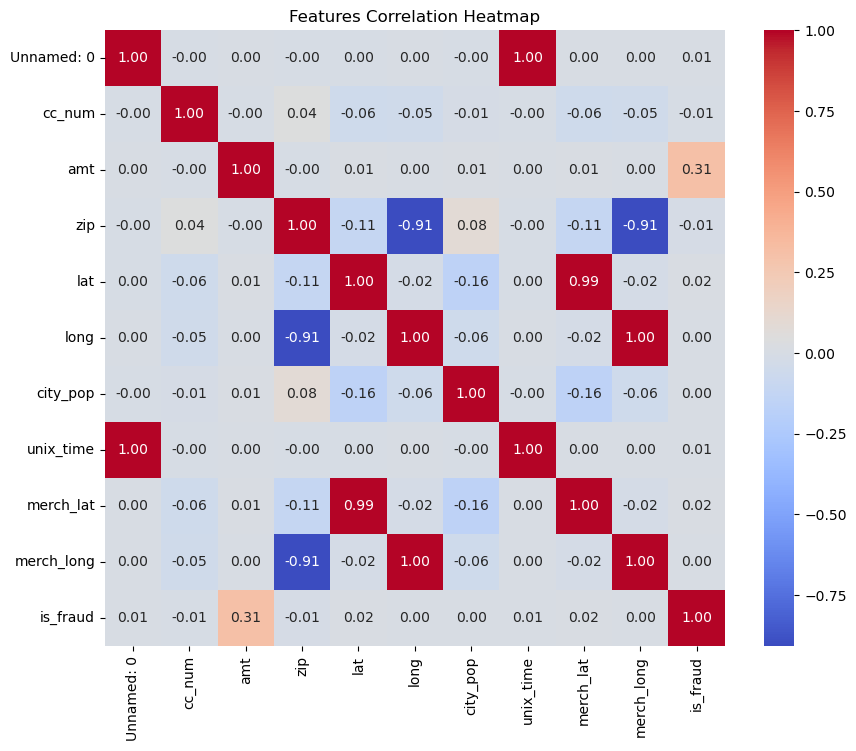

In [ ]:
#heatmap

numeric_df = data.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Features Correlation Heatmap')
plt.show()

#  merch_lat - Latitude Location of Merchant 
#  AND lat - Latitude Location of Credit Card Holder (logical correlation)
# the same for merch_lang AND LONG

# amt - Amount of Transaction and is_fraud there is a correlation of 0.31
# and they are also connected features , but we will try to clean data and fix
# some variables so we can see if there is a correlation  
#and it could be a no linear connection that s why we cant see all the vairaibles that could
# affect the target
# and we need to encode also nominal varaibles like category it could definetly affect the target
# time also


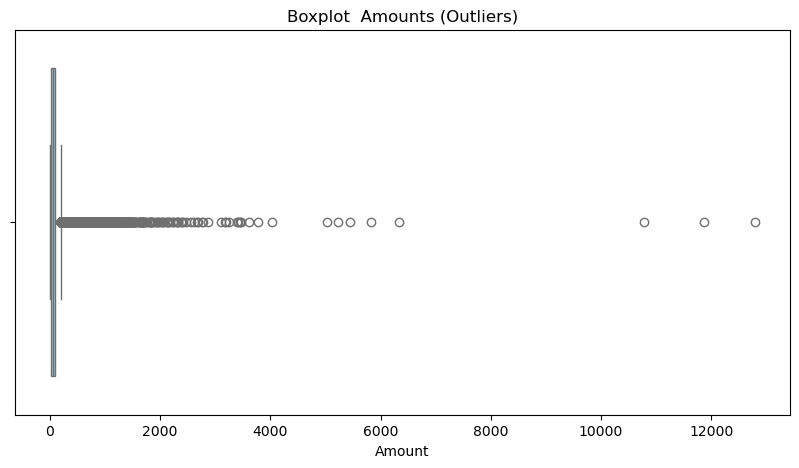

In [12]:
#outliers in amt features (amount)
plt.figure(figsize=(10, 5))
sns.boxplot(x=data['amt'], color='skyblue')
plt.title('Boxplot  Amounts (Outliers)')
plt.xlabel('Amount')
plt.show()